In [44]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Reading the file
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Soybeans Futures Historical Data.csv'].decode('utf-8')))

Saving US Soybeans Futures Historical Data.csv to US Soybeans Futures Historical Data (1).csv


In [46]:
# Convert 'date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Rename 'date' column to 'ds'
data = data.rename(columns={'Date': 'ds'})

In [48]:
# Print the first 5 rows of the dataset
print(data.head())

# Get a summary of the dataset
print(data.dtypes)

# Get summary statistics for numerical columns
print(data.describe())

          ds     Price      Open      High       Low     Vol. Change %
0 2022-12-25  1,524.00  1,495.75  1,537.50  1,485.00  321.32K    3.04%
1 2022-12-18  1,479.00  1,470.00  1,489.00  1,460.00  374.10K   -0.07%
2 2022-12-11  1,480.00  1,482.12  1,487.62  1,457.75   69.33K   -0.25%
3 2022-12-04  1,483.75  1,440.50  1,492.75  1,435.25  496.71K    3.15%
4 2022-11-27  1,438.50  1,428.25  1,478.50  1,424.00  420.75K    0.31%
ds          datetime64[ns]
Price               object
Open                object
High                object
Low                 object
Vol.                object
Change %            object
dtype: object
                         ds   Price    Open    High     Low    Vol. Change %
count                  1085    1085    1085    1085    1085     558     1085
unique                 1085     982     969     970     973     554      721
top     2022-12-25 00:00:00  569.75  563.00  594.00  526.00  31.00K    1.79%
freq                      1       4       4       4       4    

<ipython-input-48-8aa588a0b9cf>:8: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(data.describe())


In [49]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

ds          datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %            object
dtype: object


In [50]:
# Check for null values in each column
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

ds            0
Price         0
Open          0
High          0
Low           0
Vol.        527
Change %      0
dtype: int64


In [51]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

ds          0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


<ipython-input-51-4e933ffb9d75>:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())
<ipython-input-51-4e933ffb9d75>:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())


In [52]:
# Drop a column from the dataset
data = data.drop('Change %', axis=1)

# Show the updated dataset
print(data.head())

          ds    Price     Open     High      Low      Vol.
0 2022-12-25  1524.00  1495.75  1537.50  1485.00  321320.0
1 2022-12-18  1479.00  1470.00  1489.00  1460.00  374100.0
2 2022-12-11  1480.00  1482.12  1487.62  1457.75   69330.0
3 2022-12-04  1483.75  1440.50  1492.75  1435.25  496710.0
4 2022-11-27  1438.50  1428.25  1478.50  1424.00  420750.0


In [53]:
data = data.rename(columns={'Price': 'y'})
print(data.head())

          ds        y     Open     High      Low      Vol.
0 2022-12-25  1524.00  1495.75  1537.50  1485.00  321320.0
1 2022-12-18  1479.00  1470.00  1489.00  1460.00  374100.0
2 2022-12-11  1480.00  1482.12  1487.62  1457.75   69330.0
3 2022-12-04  1483.75  1440.50  1492.75  1435.25  496710.0
4 2022-11-27  1438.50  1428.25  1478.50  1424.00  420750.0


In [54]:
from prophet import Prophet

In [55]:
# Create a Prophet model
model = Prophet()

In [56]:
# Fit the model to the data
model.fit(data)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7togltje/rheo5rxv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7togltje/ysgbevgi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50618', 'data', 'file=/tmp/tmp7togltje/rheo5rxv.json', 'init=/tmp/tmp7togltje/ysgbevgi.json', 'output', 'file=/tmp/tmp7togltje/prophet_model33v_40l9/prophet_model-20230607043124.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
04:31:24 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:31:24 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [57]:
# Create future dates to make predictions
future_dates = model.make_future_dataframe(periods=7)  # 7 because weekly data
future_dates.tail()

,ds
1087,2022-12-28
1088,2022-12-29
1089,2022-12-30
1090,2022-12-31
1091,2023-01-01


In [58]:
# The predict method will assign each row in future a predicted value which it names 'yhat'.
# in - sample fit
forecast = model.predict(future_dates)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1087,2022-12-28,1526.880812,1339.124125,1712.753556
1088,2022-12-29,1528.907614,1346.669507,1717.493398
1089,2022-12-30,1530.689488,1353.022324,1721.178754
1090,2022-12-31,1532.210383,1341.560763,1719.236774
1091,2023-01-01,1533.459742,1354.691305,1722.511058


In [59]:
# Make predictions for the future dates
forecast = model.predict(future_dates)

In [60]:
# Access the forecasted values
forecasted_values = forecast[['ds', 'yhat']].tail()

# 'yhat' represents the predicted values of the target variable in the forecasting result.
# 'ds' represents the date column in the datetime format

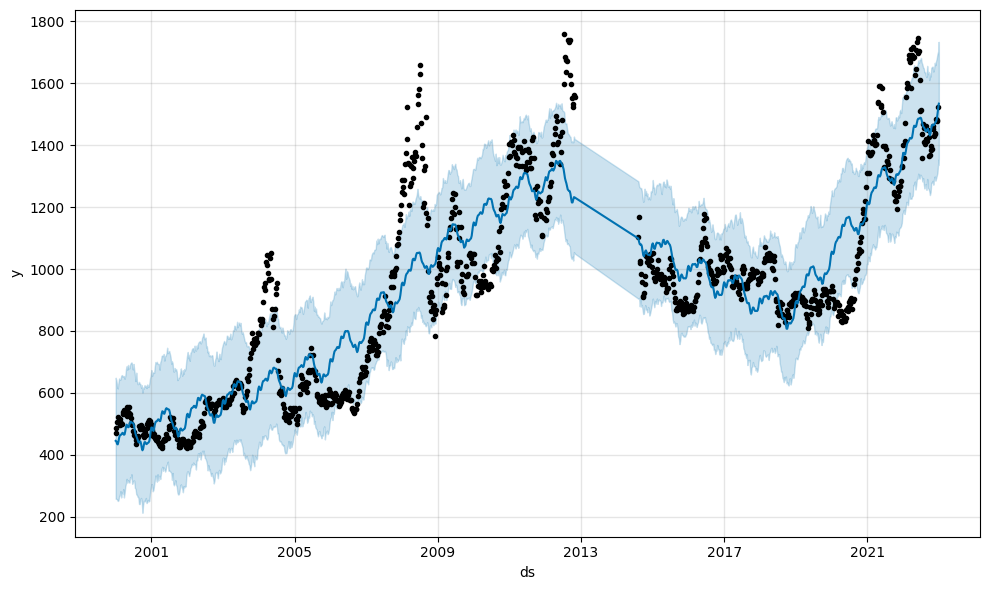

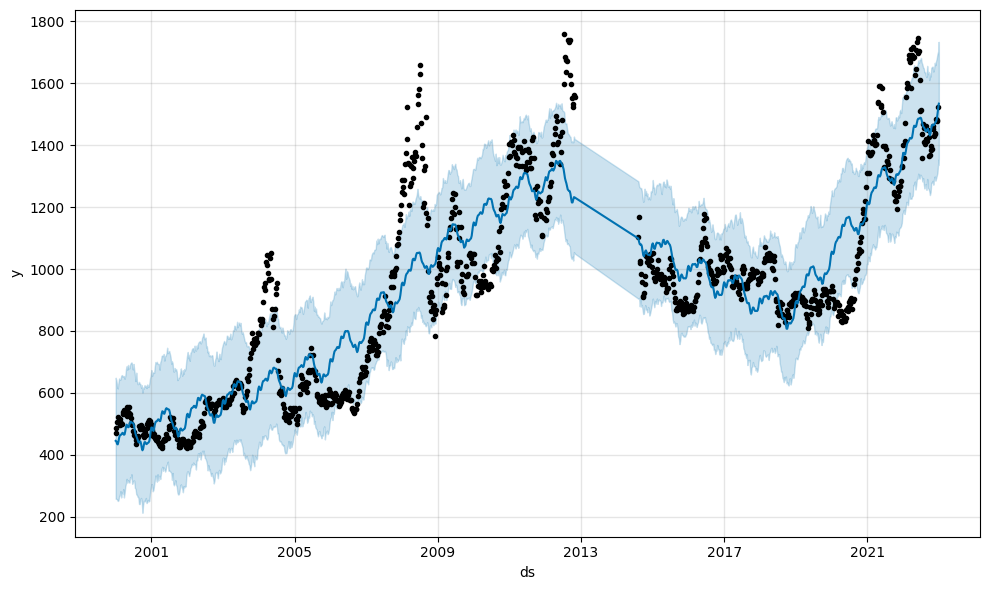

In [61]:
# Plot the forecasted values
model.plot(forecast)

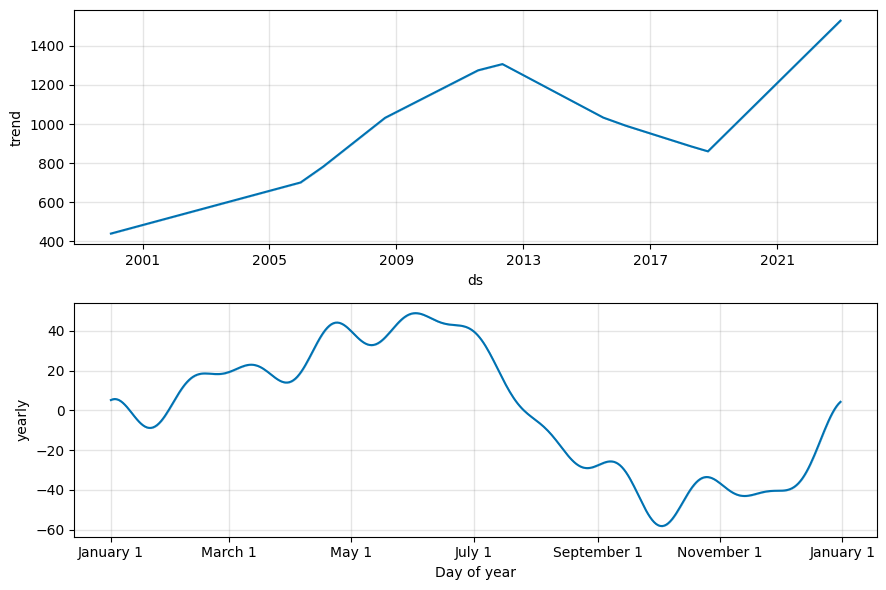

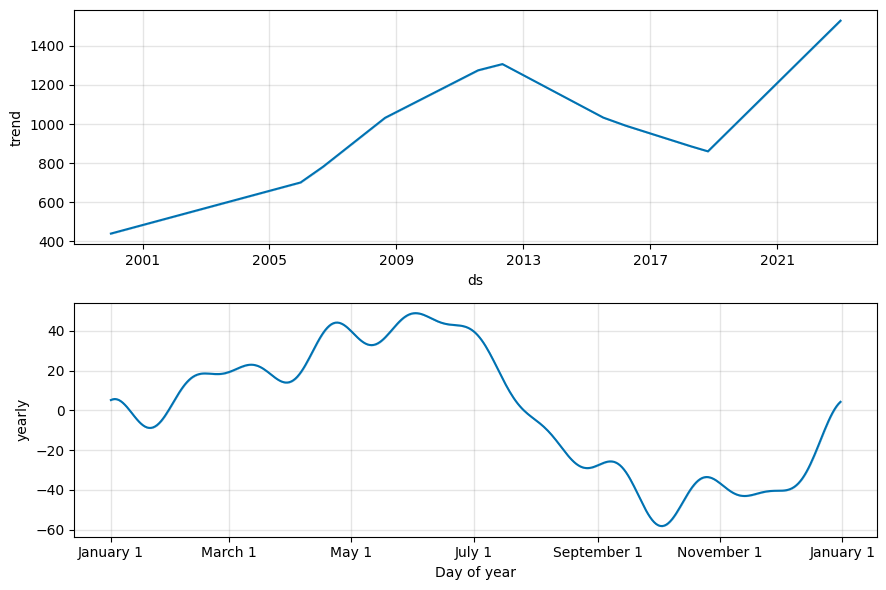

In [62]:
# Access the components of the forecast (trend, seasonality, holidays)
model.plot_components(forecast)

In [63]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [64]:
# Extract the actual values from the original dataset
actual_values = data['y'].values

In [65]:
# Extract the predicted values from the forecast dataframe
forecast = model.predict(data)
predicted_values = forecast['yhat'].values

In [66]:
# Calculate RMSE
rmse = mean_squared_error(actual_values, predicted_values, squared=False)
print('RMSE:', rmse)

RMSE: 504.09366365180085


In [67]:
from sklearn.metrics import mean_absolute_percentage_error
# Calculate MAPE using scikit-learn
mape_value = mean_absolute_percentage_error(actual_values, predicted_values)
print(mape_value)

0.5398884742645196
